# 🧠 ProSpy – Fake Social Media Profile Detection Using Neural Networks

## Overview

**ProSpy** is a machine learning project that aims to identify fake and genuine social media profiles using a **Neural Network (Deep Learning)** model. The project analyzes various profile features to learn patterns associated with fake accounts and classify them accurately.

The workflow includes data preprocessing, handling class imbalance, feature engineering, model training, evaluation, and prediction. The trained model can be integrated into applications to help detect suspicious or fraudulent social media profiles.

## Objective

- Build a neural network for fake profile detection.
- Improve prediction performance using deep learning techniques.
- Evaluate the model using appropriate classification metrics.
- Create a scalable solution that can be deployed in real-world applications.

> **Note:** Model performance depends heavily on the quality and balance of the training dataset.

### Creating The Environment

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Loading The Dataset

In [2]:
#Loading The Zipfile which contains our dataset
zip_path=r"C:\Users\DELL\Documents\GitHub\ProSpy\data\raw\archive (2).zip"

In [3]:
# Inside the zipfile we have two folders containing train and test data
import zipfile

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())

['test.csv', 'train.csv']


In [4]:
#Opening the train and test files
with zipfile.ZipFile(zip_path, 'r') as z:
    train_df=pd.read_csv(z.open('train.csv'))
    test_df=pd.read_csv(z.open('test.csv'))

### Analysing the dataset

In [5]:
# head() function is used to display the first few rows of a dataset.
print(train_df.head())
print(test_df.head())

   profile pic  nums/length username  fullname words  nums/length fullname  \
0            1                  0.27               0                   0.0   
1            1                  0.00               2                   0.0   
2            1                  0.10               2                   0.0   
3            1                  0.00               1                   0.0   
4            1                  0.00               2                   0.0   

   name==username  description length  external URL  private  #posts  \
0               0                  53             0        0      32   
1               0                  44             0        0     286   
2               0                   0             0        1      13   
3               0                  82             0        0     679   
4               0                   0             0        1       6   

   #followers  #follows  fake  
0        1000       955     0  
1        2740       533     0  
2 

In [6]:
print(train_df.columns)

Index(['profile pic', 'nums/length username', 'fullname words',
       'nums/length fullname', 'name==username', 'description length',
       'external URL', 'private', '#posts', '#followers', '#follows', 'fake'],
      dtype='str')


In [7]:
print(test_df.columns)

Index(['profile pic', 'nums/length username', 'fullname words',
       'nums/length fullname', 'name==username', 'description length',
       'external URL', 'private', '#posts', '#followers', '#follows', 'fake'],
      dtype='str')


This shows us that both train and test files contain same columns

In [8]:
#Information of the train dataset
print(train_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           576 non-null    int64  
 1   nums/length username  576 non-null    float64
 2   fullname words        576 non-null    int64  
 3   nums/length fullname  576 non-null    float64
 4   name==username        576 non-null    int64  
 5   description length    576 non-null    int64  
 6   external URL          576 non-null    int64  
 7   private               576 non-null    int64  
 8   #posts                576 non-null    int64  
 9   #followers            576 non-null    int64  
 10  #follows              576 non-null    int64  
 11  fake                  576 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 54.1 KB
None


In [9]:
#Information of the test dataset
print(test_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   profile pic           120 non-null    int64  
 1   nums/length username  120 non-null    float64
 2   fullname words        120 non-null    int64  
 3   nums/length fullname  120 non-null    float64
 4   name==username        120 non-null    int64  
 5   description length    120 non-null    int64  
 6   external URL          120 non-null    int64  
 7   private               120 non-null    int64  
 8   #posts                120 non-null    int64  
 9   #followers            120 non-null    int64  
 10  #follows              120 non-null    int64  
 11  fake                  120 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 11.4 KB
None


In [10]:
#Numerical description of the train data
train_df.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,5.760000e+02,576.000000,576.000000
mean,0.701389,0.163837,1.460069,0.036094,0.034722,22.623264,0.116319,0.381944,107.489583,8.530724e+04,508.381944,0.500000
std,0.458047,0.214096,1.052601,0.125121,0.183234,37.702987,0.320886,0.486285,402.034431,9.101485e+05,917.981239,0.500435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.900000e+01,57.500000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.505000e+02,229.500000,0.500000
75%,1.000000,0.310000,2.000000,0.000000,0.000000,34.000000,0.000000,1.000000,81.500000,7.160000e+02,589.500000,1.000000
max,1.000000,0.920000,12.000000,1.000000,1.000000,150.000000,1.000000,1.000000,7389.000000,1.533854e+07,7500.000000,1.000000


In [11]:
#Numerical description of the test data
test_df.describe()

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,1.200000e+02,120.000000,120.000000
mean,0.758333,0.179917,1.550000,0.071333,0.041667,27.200000,0.100000,0.308333,82.866667,4.959472e+04,779.266667,0.500000
std,0.429888,0.241492,1.187116,0.209429,0.200664,42.588632,0.301258,0.463741,230.468136,3.816126e+05,1409.383558,0.502096
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000
25%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.725000e+01,119.250000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2.165000e+02,354.500000,0.500000
75%,1.000000,0.330000,2.000000,0.000000,0.000000,45.250000,0.000000,1.000000,58.250000,5.932500e+02,668.250000,1.000000
max,1.000000,0.890000,9.000000,1.000000,1.000000,149.000000,1.000000,1.000000,1879.000000,4.021842e+06,7453.000000,1.000000


In [12]:
#Number of rows and columns in out train data
train_df.shape

(576, 12)

In [13]:
#Number of rows and columns in out test data
test_df.shape

(120, 12)

### Cleaning The Dataset

In [14]:
#Checking wheather train dataset has null values
print(train_df.isnull().sum())

profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64


In [15]:
#Checking wheather test dataset has null values
print(test_df.isnull().sum())

profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64


This shows us that both train and test data do not have any null values

In [16]:
#Checking wheather train dataset has any duplicate values (if it does have, we will remove them)
print(train_df.duplicated().sum())

2


In [17]:
#Removing the 2 duplicate rows
train_df.drop_duplicates(inplace = True)

In [18]:
#Again checking the train dataset for duplicate rows
print(train_df.duplicated().sum())

0


In [19]:
#Doing the same for test data
print(test_df.duplicated().sum())

2


In [20]:
#Removing the 2 duplicate rows
test_df.drop_duplicates(inplace = True)

In [21]:
#Again checking the test dataset for duplicate rows
print(test_df.duplicated().sum())

0


In [22]:
print(train_df.shape)
print(test_df.shape)

(574, 12)
(118, 12)


In [23]:
train_clean_df = train_df.copy()
test_clean_df = test_df.copy()

### EDA (Exploratory Data Analysis) - Part 01(Data Representation)

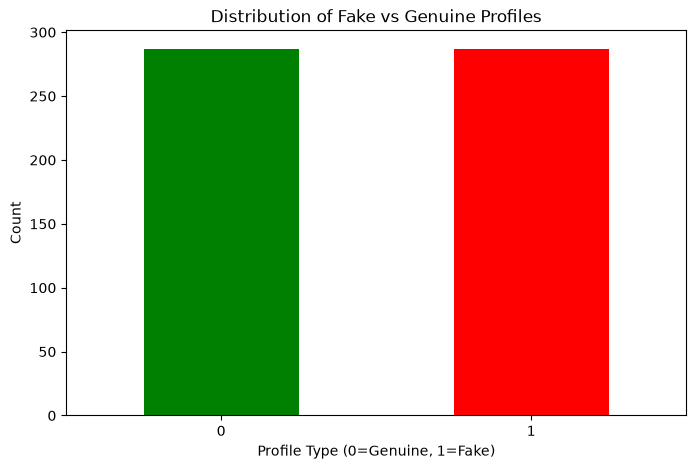

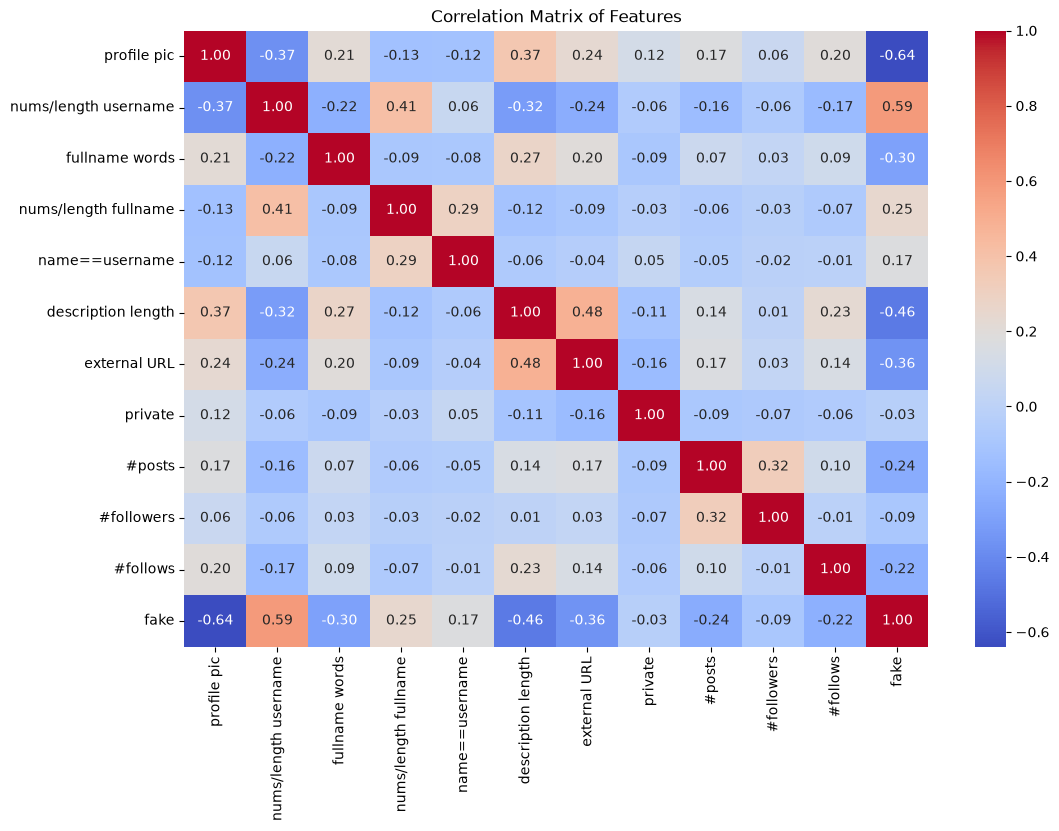

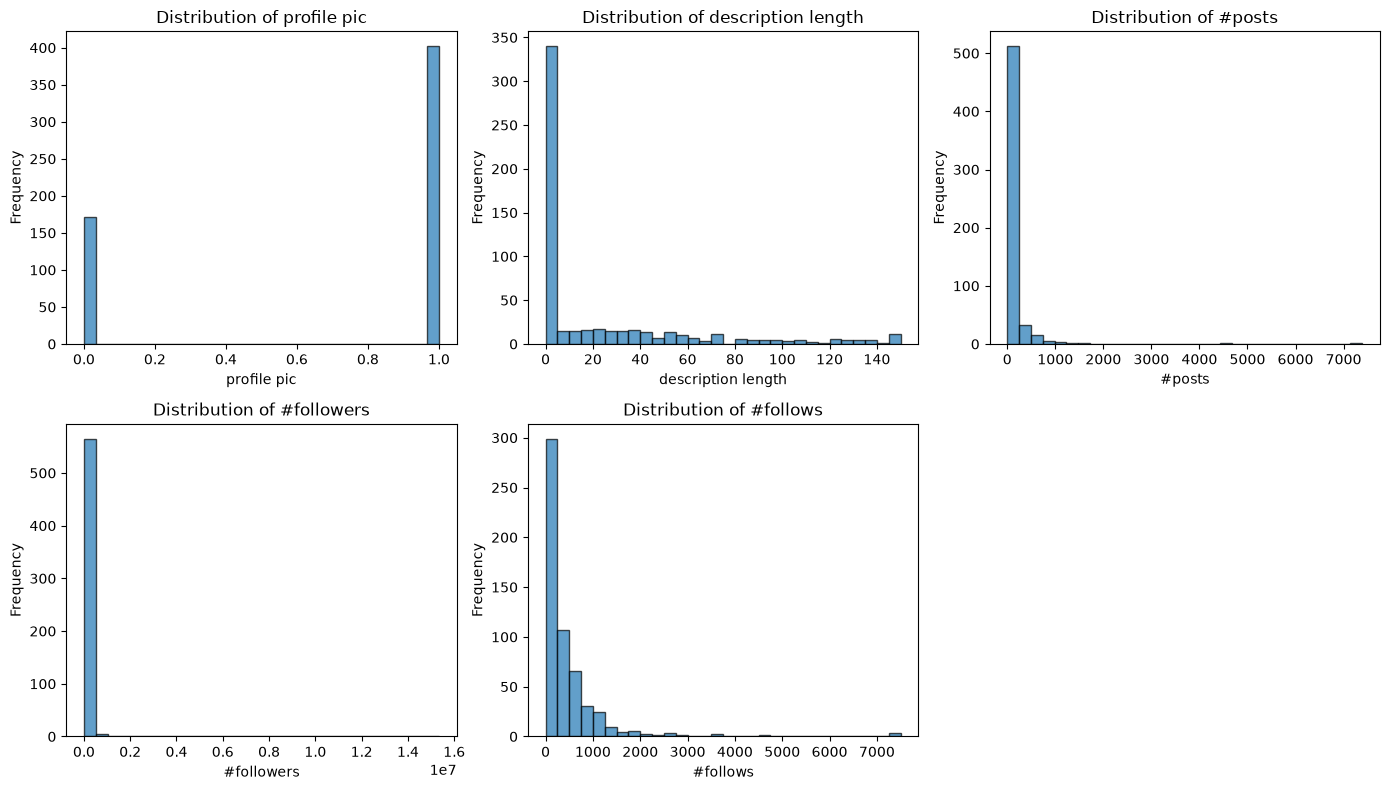

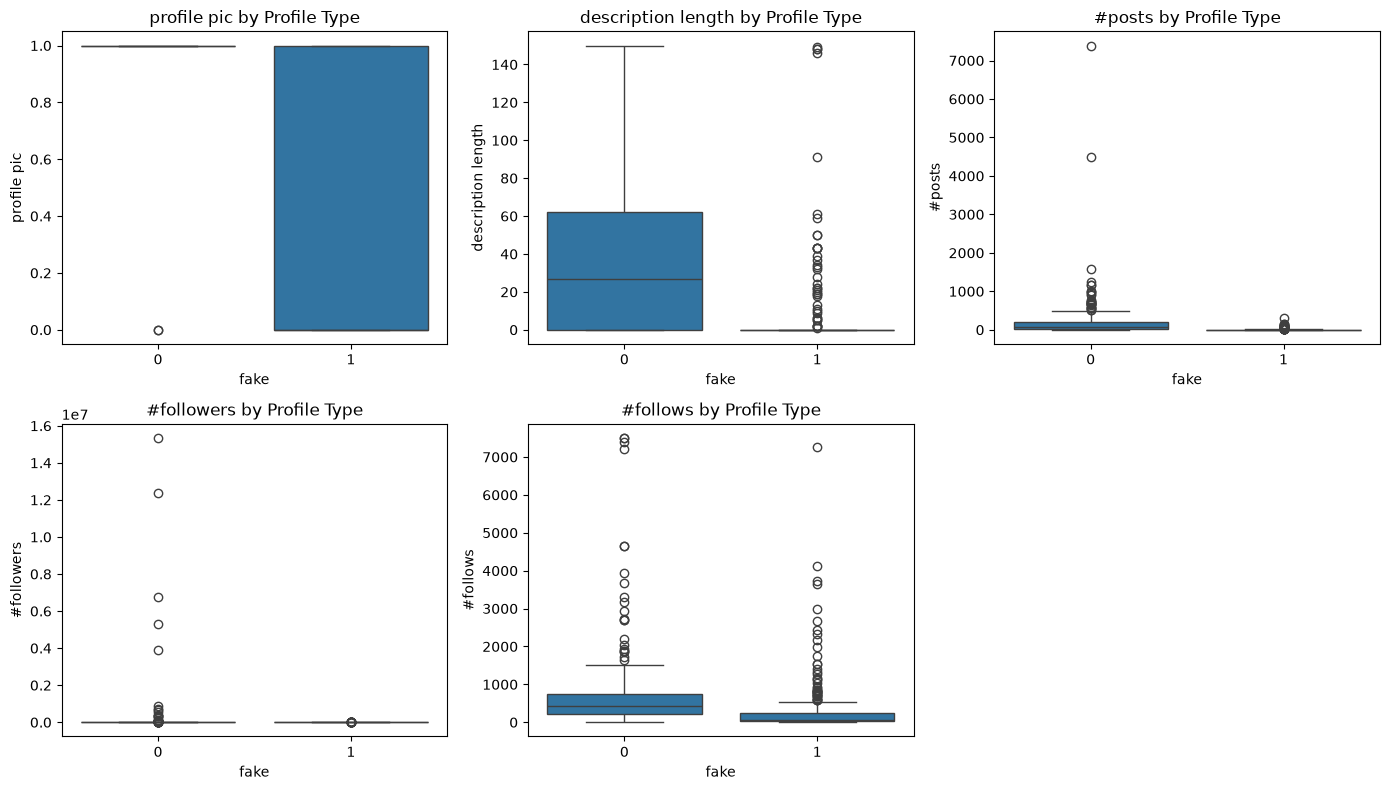

In [24]:
# Distribution of fake vs genuine profiles
plt.figure(figsize=(8, 5))
train_clean_df['fake'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Fake vs Genuine Profiles')
plt.xlabel('Profile Type (0=Genuine, 1=Fake)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(train_clean_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

# Distribution of key features
features_to_plot = ['profile pic', 'description length', '#posts', '#followers', '#follows']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for idx, feature in enumerate(features_to_plot):
    axes[idx].hist(train_clean_df[feature], bins=30, alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

# Box plots for fake vs genuine
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for idx, feature in enumerate(features_to_plot):
    sns.boxplot(data=train_clean_df, x='fake', y=feature, ax=axes[idx])
    axes[idx].set_title(f'{feature} by Profile Type')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### EDA - Part 02 (Statistical Data)

In [25]:
from scipy import stats

# Statistical summary for genuine vs fake profiles
print("=" * 60)
print("STATISTICAL ANALYSIS: GENUINE VS FAKE PROFILES")
print("=" * 60)

# Overall statistics
print("\nGenuine Profiles (fake=0):")
print(train_clean_df[train_clean_df['fake'] == 0].describe())

print("\n" + "=" * 60)
print("Fake Profiles (fake=1):")
print(train_clean_df[train_clean_df['fake'] == 1].describe())

# Mean comparison
print("\n" + "=" * 60)
print("MEAN VALUES COMPARISON")
print("=" * 60)
comparison_df = train_clean_df.groupby('fake')[features_to_plot].mean()
print(comparison_df)

# Statistical tests (T-test for each feature)

print("\n" + "=" * 60)
print("T-TEST RESULTS (Genuine vs Fake)")
print("=" * 60)
genuine = train_clean_df[train_clean_df['fake'] == 0]
fake = train_clean_df[train_clean_df['fake'] == 1]

for feature in features_to_plot:
    t_stat, p_value = stats.ttest_ind(genuine[feature], fake[feature])
    print(f"{feature}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")

STATISTICAL ANALYSIS: GENUINE VS FAKE PROFILES

Genuine Profiles (fake=0):
       profile pic  nums/length username  fullname words  \
count   287.000000            287.000000      287.000000   
mean      0.993031              0.038258        1.773519   
std       0.083332              0.088719        1.251962   
min       0.000000              0.000000        0.000000   
25%       1.000000              0.000000        1.000000   
50%       1.000000              0.000000        2.000000   
75%       1.000000              0.000000        2.000000   
max       1.000000              0.450000       12.000000   

       nums/length fullname  name==username  description length  external URL  \
count            287.000000      287.000000          287.000000    287.000000   
mean               0.005261        0.003484           39.954704      0.233449   
std                0.034171        0.059028           42.865965      0.423765   
min                0.000000        0.000000            0.000

### Data Summary

In [26]:
# Data summary cell
print("DATA SUMMARY :")
print("...............................")
def data_summary(df, name="Dataset"):
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nDuplicates:", df.duplicated().sum())
    vc = df['fake'].value_counts().to_frame('count')
    vc['percent'] = (vc['count'] / vc['count'].sum() * 100).round(2)
    print("\nClass distribution (fake):\n", vc)
    print("\nNumeric summary (rounded):")
    display(df.describe().round(3))
    cor_with_fake = df.corr()['fake'].drop('fake').abs().sort_values(ascending=False)
    print("\nTop correlations with 'fake':")
    display(cor_with_fake.to_frame('abs_corr_with_fake').round(3))
    print("\nTop 5 by #followers:")
    display(df.nlargest(5, '#followers')[['#followers', '#posts', '#follows', 'description length', 'profile pic', 'fake']])
    print("\nBottom 5 by #followers:")
    display(df.nsmallest(5, '#followers')[['#followers', '#posts', '#follows', 'description length', 'profile pic', 'fake']])
    print("\n")

# Summarize train and test
data_summary(train_clean_df, "Train Clean")
data_summary(test_clean_df, "Test Clean")

# Mean comparison (genuine vs fake) from existing computation
print("=== Mean comparison (fake vs genuine) ===")
display(comparison_df.round(3))

DATA SUMMARY :
...............................
=== Train Clean ===
Shape: (574, 12)

Missing values:
 profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64

Duplicates: 0

Class distribution (fake):
       count  percent
fake                
0       287     50.0
1       287     50.0

Numeric summary (rounded):


,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake
count,574.000,574.000,574.000,574.000,574.000,574.000,574.000,574.000,574.000,5.740000e+02,574.000,574.0
mean,0.700,0.163,1.460,0.036,0.035,22.618,0.117,0.383,107.477,8.559514e+04,508.972,0.5
std,0.459,0.212,1.054,0.125,0.184,37.742,0.321,0.487,402.682,9.117223e+05,919.341,0.5
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000000e+00,0.000,0.0
25%,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,3.900000e+01,58.000,0.0
50%,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,9.000,1.505000e+02,229.500,0.5
75%,1.000,0.310,2.000,0.000,0.000,34.000,0.000,1.000,80.750,7.132500e+02,587.750,1.0
max,1.000,0.920,12.000,1.000,1.000,150.000,1.000,1.000,7389.000,1.533854e+07,7500.000,1.0



Top correlations with 'fake':


,abs_corr_with_fake
profile pic,0.639
nums/length username,0.588
description length,0.460
external URL,0.364
fullname words,0.298
nums/length fullname,0.247
#posts,0.245
#follows,0.224
name==username,0.171
#followers,0.094



Top 5 by #followers:


...

,#followers,#posts,#follows,description length,profile pic,fake
29,4021842,1879,5514,147,1,0
41,1027419,932,293,84,1,0
49,602517,307,482,133,1,0
26,155537,1065,1395,137,1,0
32,81267,90,963,117,1,0



Bottom 5 by #followers:


,#followers,#posts,#follows,description length,profile pic,fake
60,0,0,2,0,0,1
72,0,0,18,0,0,1
66,9,0,25,0,0,1
78,10,2,24,0,1,1
76,13,0,22,0,0,1




=== Mean comparison (fake vs genuine) ===


,profile pic,description length,#posts,#followers,#follows
fake,,,,,
0,0.993,39.955,205.990,171079.571,714.815
1,0.408,5.282,8.965,110.711,303.129


This shows us that our data is balanced and is ready to use

### Preprocessing The Data

In [27]:
# 1) Feature engineering
def add_profile_features(df):
    df = df.copy()
    df['followers_to_follows'] = df['#followers'] / df['#follows'].replace(0, 1)
    df['posts_per_follower'] = df['#posts'] / df['#followers'].replace(0, 1)
    df['log_description_length'] = np.log1p(df['description length'])
    df['log_posts'] = np.log1p(df['#posts'])
    df['log_followers'] = np.log1p(df['#followers'])
    df['log_follows'] = np.log1p(df['#follows'])
    return df

train_features_df = add_profile_features(train_clean_df)
test_features_df = add_profile_features(test_clean_df)

# 2) Encode categorical features
categorical_cols = ['profile pic', 'name==username', 'external URL', 'private']
for col in categorical_cols:
    train_features_df[col] = train_features_df[col].astype(int)
    test_features_df[col] = test_features_df[col].astype(int)

# 3) Define features to use
feature_columns = [
    'profile pic',
    'nums/length username',
    'fullname words',
    'nums/length fullname',
    'name==username',
    'description length',
    'external URL',
    'private',
    '#posts',
    '#followers',
    '#follows',
    'followers_to_follows',
    'posts_per_follower',
    'log_description_length',
    'log_posts',
    'log_followers',
    'log_follows'
]

# 4) Scale numerical features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(train_features_df[feature_columns]),
    columns=feature_columns,
    index=train_features_df.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(test_features_df[feature_columns]),
    columns=feature_columns,
    index=test_features_df.index
)

y_train = train_features_df['fake'].copy()
y_test = test_features_df['fake'].copy()

# 5) Feature selection based on correlation with target
corr_with_target = pd.concat([X_train_scaled, y_train], axis=1).corr()['fake'].abs().sort_values(ascending=False)
selected_features = corr_with_target.drop('fake').nlargest(10).index.tolist()

print("Selected features based on correlation with target:")
print(selected_features)

X_train_processed = X_train_scaled[selected_features]
X_test_processed = X_test_scaled[selected_features]


print("\nFinal preprocessed shapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Selected features based on correlation with target:
['log_posts', 'log_followers', 'profile pic', 'log_description_length', 'nums/length username', 'log_follows', 'description length', 'external URL', 'fullname words', 'nums/length fullname']

Final preprocessed shapes:
X_train_processed: (574, 10)
X_test_processed: (118, 10)
y_train: (574,)
y_test: (118,)


### Splitting The Dataset

> **Note:** Our Dataset already contains different files for train and test data, so we will simply split the train data to train and validation

In [28]:
# Split the processed training data into train + validation, keeping the original test set separate
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_processed,
    y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

X_test_final = X_test_processed
y_test_final = y_test

print("Dataset splits:")
print(f"  Train:      {X_train_final.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test:       {X_test_final.shape[0]} samples")

total_samples = X_train_final.shape[0] + X_val.shape[0] + X_test_final.shape[0]
print("\nSplit ratios:")
print(f"  Train:      {X_train_final.shape[0] / total_samples:.2%}")
print(f"  Validation: {X_val.shape[0] / total_samples:.2%}")
print(f"  Test:       {X_test_final.shape[0] / total_samples:.2%}")

print("\nClass balance (train / validation / test):")
print("  Train:\n", y_train_final.value_counts(normalize=True).sort_index())
print("  Validation:\n", y_val.value_counts(normalize=True).sort_index())
print("  Test:\n", y_test_final.value_counts(normalize=True).sort_index())

Dataset splits:
  Train:      487 samples
  Validation: 87 samples
  Test:       118 samples

Split ratios:
  Train:      70.38%
  Validation: 12.57%
  Test:       17.05%

Class balance (train / validation / test):
  Train:
 fake
0    0.498973
1    0.501027
Name: proportion, dtype: float64
  Validation:
 fake
0    0.505747
1    0.494253
Name: proportion, dtype: float64
  Test:
 fake
0    0.508475
1    0.491525
Name: proportion, dtype: float64


### Training The Model Using Nueral Networks

#### Building the Neural Network

In [29]:
# Build the Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_final.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Model


In [30]:
# Train the model
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_final,
    y_train_final,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6037 - loss: 0.6386 - val_accuracy: 0.8736 - val_loss: 0.5645
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7782 - loss: 0.5473 - val_accuracy: 0.9310 - val_loss: 0.4746
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8419 - loss: 0.4798 - val_accuracy: 0.9310 - val_loss: 0.3845
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8871 - loss: 0.3935 - val_accuracy: 0.9425 - val_loss: 0.3062
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9117 - loss: 0.3292 - val_accuracy: 0.9310 - val_loss: 0.2409
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9158 - loss: 0.2738 - val_accuracy: 0.9195 - val_loss: 0.2064
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9158 - loss: 0.2371 - val_accuracy: 0.9310 - val_loss: 0.1909
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9117 - loss: 0.2149 - val_accuracy: 0.9425

Basically our model stpped at 58 epochs iteration instead of a 100 because we had used earlystp to stop the iteration when minimum validation loss is acheived.

### Evaluating The model 

MODEL EVALUATION
....................
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Accuracy Scores:
  Train Accuracy: 0.9569
  Validation Accuracy: 0.9310
  Test Accuracy: 0.9153

........................................................................................................................................................................................................................................................................................................................................................................
CONFUSION MATRICES
........................................................................................................................................................................................................................................................................................................................................................................

Train S

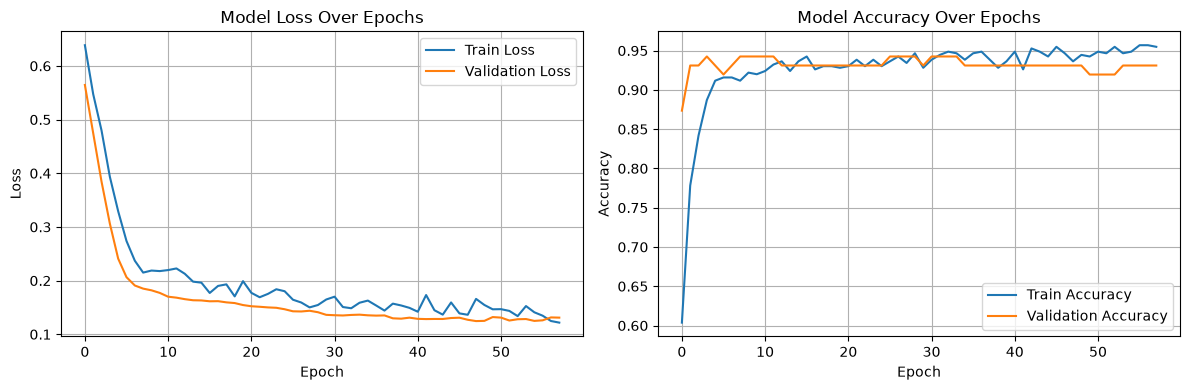

In [31]:
# Evaluate the model on train, validation, and test sets
print("MODEL EVALUATION")
print("....................")

# Predictions
y_train_pred = model.predict(X_train_final)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test_final)

# Convert probabilities to binary predictions
y_train_pred_binary = (y_train_pred > 0.5).astype(int).flatten()
y_val_pred_binary = (y_val_pred > 0.5).astype(int).flatten()
y_test_pred_binary = (y_test_pred > 0.5).astype(int).flatten()

# Calculate accuracy
train_accuracy = accuracy_score(y_train_final, y_train_pred_binary)
val_accuracy = accuracy_score(y_val, y_val_pred_binary)
test_accuracy = accuracy_score(y_test_final, y_test_pred_binary)

print(f"\nAccuracy Scores:")
print(f"  Train Accuracy: {train_accuracy:.4f}")
print(f"  Validation Accuracy: {val_accuracy:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}")

# Confusion matrices
print("\n" + "......" * 60)
print("CONFUSION MATRICES")
print("......" * 60)

print("\nTrain Set Confusion Matrix:")
print(confusion_matrix(y_train_final, y_train_pred_binary))

print("\nValidation Set Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_binary))

print("\nTest Set Confusion Matrix:")
print(confusion_matrix(y_test_final, y_test_pred_binary))

# Classification reports
print("\n" + "......." * 60)
print("CLASSIFICATION REPORTS")
print("........" * 60)

print("\nTrain Set Classification Report:")
print(classification_report(y_train_final, y_train_pred_binary, target_names=['Genuine', 'Fake']))

print("\nValidation Set Classification Report:")
print(classification_report(y_val, y_val_pred_binary, target_names=['Genuine', 'Fake']))

print("\nTest Set Classification Report:")
print(classification_report(y_test_final, y_test_pred_binary, target_names=['Genuine', 'Fake']))

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [32]:
print("....." * 60)
print()
print("CLASSIFICATION REPORT :")
print()
print()

from sklearn.metrics import precision_recall_fscore_support

# Create a comprehensive classification report visualization
import matplotlib.patches as mpatches

# Calculate metrics for all datasets
datasets = {
    'Train': (y_train_final, y_train_pred_binary),
    'Validation': (y_val, y_val_pred_binary),
    'Test': (y_test_final, y_test_pred_binary)
}

metrics_summary = []
for dataset_name, (y_true, y_pred) in datasets.items():
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    metrics_summary.append({
        'Dataset': dataset_name,
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'F1-Score': f'{f1:.4f}',
        'Accuracy': f'{accuracy_score(y_true, y_pred):.4f}'
    })

metrics_df = pd.DataFrame(metrics_summary)
print("\n" + "=" * 70)
print("CLASSIFICATION METRICS SUMMARY")
print("=" * 70)
print(metrics_df.to_string(index=False))

............................................................................................................................................................................................................................................................................................................

CLASSIFICATION REPORT :



CLASSIFICATION METRICS SUMMARY
   Dataset Precision Recall F1-Score Accuracy
     Train    0.9569 0.9569   0.9569   0.9569
Validation    0.9319 0.9310   0.9310   0.9310
      Test    0.9158 0.9153   0.9153   0.9153


In [33]:
# Summary of model performance metrics
print("=" * 70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 70)

summary_data = {
    'Dataset': ['Train', 'Validation', 'Test'],
    'Accuracy': [f'{train_accuracy:.4f}', f'{val_accuracy:.4f}', f'{test_accuracy:.4f}'],
    'Samples': [X_train_final.shape[0], X_val.shape[0], X_test_final.shape[0]]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)
print(f"✓ Best performing on: {'Test' if test_accuracy == max(train_accuracy, val_accuracy, test_accuracy) else 'Validation' if val_accuracy == max(train_accuracy, val_accuracy, test_accuracy) else 'Train'}")
print(f"✓ Overall accuracy across all sets: {(train_accuracy + val_accuracy + test_accuracy) / 3:.4f}")
print(f"✓ Model generalization: {'Good' if abs(train_accuracy - test_accuracy) < 0.05 else 'Moderate' if abs(train_accuracy - test_accuracy) < 0.10 else 'Poor'}")

FINAL MODEL PERFORMANCE SUMMARY
   Dataset Accuracy  Samples
     Train   0.9569      487
Validation   0.9310       87
      Test   0.9153      118

KEY INSIGHTS
✓ Best performing on: Train
✓ Overall accuracy across all sets: 0.9344
✓ Model generalization: Good


### Test On New Data

In [34]:
# Test on new/unseen profile data and verify predictions

# Example unseen profiles (adjust values as needed)
new_profiles = [
    {
        'profile pic': 1,
        'nums/length username': 0.20,
        'fullname words': 1,
        'nums/length fullname': 0.00,
        'name==username': 0,
        'description length': 45,
        'external URL': 0,
        'private': 0,
        '#posts': 12,
        '#followers': 1200,
        '#follows': 950
    },
    {
        'profile pic': 0,
        'nums/length username': 0.10,
        'fullname words': 0,
        'nums/length fullname': 0.00,
        'name==username': 1,
        'description length': 2,
        'external URL': 0,
        'private': 1,
        '#posts': 1,
        '#followers': 15,
        '#follows': 300
    }
]

# Create dataframe and apply same feature engineering + encoding + scaling + selection
df_new = pd.DataFrame(new_profiles)
df_new = add_profile_features(df_new)

# Ensure categorical encoding matches training
for col in categorical_cols:
    df_new[col] = df_new[col].astype(int)

# Scale and select features
X_new_scaled = pd.DataFrame(scaler.transform(df_new[feature_columns]), columns=feature_columns, index=df_new.index)
X_new = X_new_scaled[selected_features]

# Predict
probs = model.predict(X_new).flatten()
preds = (probs > 0.5).astype(int)

# Prepare and show results
df_new_results = df_new.copy()
df_new_results['pred_prob'] = probs
df_new_results['pred_label'] = np.where(preds == 1, 'Fake', 'Genuine')

print(df_new_results[[
    'profile pic', 'nums/length username', 'fullname words', 'description length',
    '#posts', '#followers', '#follows', 'pred_prob', 'pred_label'
]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
   profile pic  nums/length username  fullname words  description length  \
0            1                   0.2               1                  45   
1            0                   0.1               0                   2   

   #posts  #followers  #follows  pred_prob pred_label  
0      12        1200       950   0.081159    Genuine  
1       1          15       300   0.999897       Fake  


### Saving The Model

In [35]:
best_model_keras_path = "best_model.keras"
# save in native Keras format
model.save(best_model_keras_path)
print(f"Saved model in Keras format to {best_model_keras_path}")

Saved model in Keras format to best_model.keras
